# 01 - Dataset, Queries, and Qrels Audit


الداتاسيت المستخدمة:
`medline/2004/trec-genomics-2005`

رابط صفحة الداتاسيت الرسمية على ir-datasets:
https://ir-datasets.com/medline.html#medline/2004/trec-genomics-2005

In [1]:
from pathlib import Path
import sys, os, json, sqlite3, subprocess, time
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# يستطيع صديقك تغيير هذا المتغير إذا كانت artifacts خارج المشروع.
# مثال في PowerShell قبل فتح notebook:
# $env:IR_ARTIFACT_ROOT="E:\\ir_project_artifacts"
ARTIFACT_ROOT = Path(os.environ.get("IR_ARTIFACT_ROOT", r"E:\ir_project_artifacts"))


def first_existing(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            return p
    return Path(paths[0])

DB_PATH = first_existing([
    PROJECT_ROOT / "data" / "documents.sqlite",
    PROJECT_ROOT / "data" / "documents.db",
    ARTIFACT_ROOT / "documents.sqlite",
    ARTIFACT_ROOT / "documents.db",
])

TERRIER_INDEX_PATH = first_existing([
    PROJECT_ROOT / "indexes" / "terrier_medline",
    PROJECT_ROOT / "data" / "indexes" / "terrier_medline",
    ARTIFACT_ROOT / "indexes" / "terrier_medline",
])

BERT_INDEX_DIR = first_existing([
    PROJECT_ROOT / "indexes" / "faiss_bert",
    PROJECT_ROOT / "indexes" / "faiss_bert_full",
    PROJECT_ROOT / "data" / "rag_artifacts",
    ARTIFACT_ROOT / "indexes" / "faiss_bert_full",
    ARTIFACT_ROOT / "indexes" / "faiss_bert",
])

WORD2VEC_INDEX_DIR = first_existing([
    PROJECT_ROOT / "indexes" / "faiss_word2vec",
    PROJECT_ROOT / "indexes" / "faiss_word2vec_full",
    ARTIFACT_ROOT / "indexes" / "faiss_word2vec_full",
    ARTIFACT_ROOT / "indexes" / "faiss_word2vec",
])

REPORTS_DIR = PROJECT_ROOT / "reports" / "evaluation_notebook"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT       =", PROJECT_ROOT)
print("ARTIFACT_ROOT      =", ARTIFACT_ROOT)
print("DB_PATH            =", DB_PATH, "exists=", DB_PATH.exists())
print("TERRIER_INDEX_PATH =", TERRIER_INDEX_PATH, "exists=", TERRIER_INDEX_PATH.exists())
print("BERT_INDEX_DIR     =", BERT_INDEX_DIR, "exists=", BERT_INDEX_DIR.exists())
print("WORD2VEC_INDEX_DIR =", WORD2VEC_INDEX_DIR, "exists=", WORD2VEC_INDEX_DIR.exists())

PROJECT_ROOT       = e:\in Desktop\IR_Project\IR
ARTIFACT_ROOT      = E:\ir_project_artifacts
DB_PATH            = E:\ir_project_artifacts\documents.sqlite exists= True
TERRIER_INDEX_PATH = E:\ir_project_artifacts\indexes\terrier_medline exists= True
BERT_INDEX_DIR     = E:\ir_project_artifacts\indexes\faiss_bert_full exists= True
WORD2VEC_INDEX_DIR = E:\ir_project_artifacts\indexes\faiss_word2vec_full exists= True


In [2]:
from IPython.display import display, Markdown
DATASET_ID = "medline/2004/trec-genomics-2005"
DATASET_URL = "https://ir-datasets.com/medline.html#medline/2004/trec-genomics-2005"

print("Dataset ID:", DATASET_ID)
print("Official dataset URL:", DATASET_URL)
display(Markdown(f"**Open dataset page:** [{DATASET_ID}]({DATASET_URL})"))

Dataset ID: medline/2004/trec-genomics-2005
Official dataset URL: https://ir-datasets.com/medline.html#medline/2004/trec-genomics-2005


**Open dataset page:** [medline/2004/trec-genomics-2005](https://ir-datasets.com/medline.html#medline/2004/trec-genomics-2005)

In [3]:
from src.datasets.loader import load_queries, load_qrels

queries_df = load_queries("main")
qrels_df = load_qrels("main")

print("Number of queries loaded for evaluation:", len(queries_df))
print("Number of qrels loaded for evaluation:", len(qrels_df))
print("Unique query_id in qrels:", qrels_df["query_id"].astype(str).nunique())
print("Unique doc_id in qrels:", qrels_df["doc_id"].astype(str).nunique())
print("Relevance values:", sorted(qrels_df["relevance"].unique()))

display(queries_df.head())
display(qrels_df.head())

Number of queries loaded for evaluation: 50
Number of qrels loaded for evaluation: 39958
Unique query_id in qrels: 49
Unique doc_id in qrels: 34633
Relevance values: [np.int64(0), np.int64(1), np.int64(2)]


,query_id,text
0,100,"Describe the procedure or methods for how to ""..."
1,101,Describe the procedure or methods for exact re...
2,102,Describe the procedure or methods for differen...
3,103,Describe the procedure or methods for green fl...
4,104,Describe the procedure or methods for how to d...


,query_id,doc_id,relevance,iteration
0,100,10023709,0,0
1,100,10051592,0,0
2,100,10066453,2,0
3,100,10071611,0,0
4,100,10081001,1,0


Qrels relevance distribution:


,relevance,count
0,0,35374
1,1,2059
2,2,2525


Text(0, 0.5, 'Count')

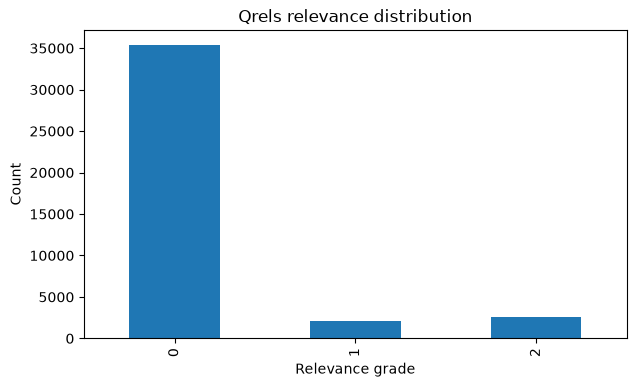

In [4]:
# توزيع درجات الـ relevance في qrels
rel_dist = qrels_df["relevance"].value_counts().sort_index().rename_axis("relevance").reset_index(name="count")
print("Qrels relevance distribution:")
display(rel_dist)

ax = rel_dist.plot(kind="bar", x="relevance", y="count", legend=False, figsize=(7,4), title="Qrels relevance distribution")
ax.set_xlabel("Relevance grade")
ax.set_ylabel("Count")

Queries with qrels: 49
Min qrels per query: 288
Max qrels per query: 1356
Average qrels per query: 815.47


,query_id,qrels_count
0,100,704
1,101,651
2,102,1164
3,103,701
4,104,629
5,105,1133
6,106,1230
7,107,484
8,108,1092
9,109,389


Text(0.5, 0, 'Qrels count')

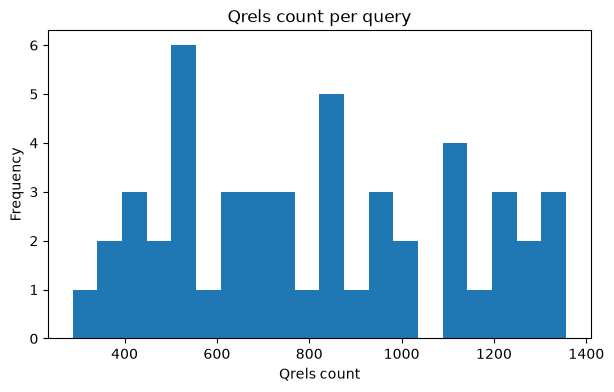

In [5]:
# عدد qrels لكل query، هذا مهم لإثبات أن التقييم ليس على query واحدة فقط.
qrels_per_query = qrels_df.groupby("query_id").size().reset_index(name="qrels_count")
print("Queries with qrels:", len(qrels_per_query))
print("Min qrels per query:", qrels_per_query["qrels_count"].min())
print("Max qrels per query:", qrels_per_query["qrels_count"].max())
print("Average qrels per query:", round(qrels_per_query["qrels_count"].mean(), 2))
display(qrels_per_query.head(10))

ax = qrels_per_query["qrels_count"].plot(kind="hist", bins=20, figsize=(7,4), title="Qrels count per query")
ax.set_xlabel("Qrels count")

In [6]:
# فحص اختياري من SQLite إذا كان موجوداً.
if DB_PATH.exists():
    with sqlite3.connect(DB_PATH) as conn:
        tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)
        print("SQLite tables:")
        display(tables)
        if "queries" in set(tables["name"]):
            q_count = pd.read_sql_query("SELECT COUNT(*) AS sqlite_queries FROM queries", conn)
            display(q_count)
        if "qrels" in set(tables["name"]):
            qr_count = pd.read_sql_query("SELECT COUNT(*) AS sqlite_qrels FROM qrels", conn)
            display(qr_count)
else:
    print("SQLite file not found; dataset/qrels audit used ir_datasets directly.")

SQLite tables:


,name
0,documents
